In [28]:
# 卷积神经网络的诞生
# 我们之前学习的MLP很适合处理表格数据，行对应样本，列对应特征，但是如果遇到更高维的数据，比如图像，就不那么合适了
# 比如一个图片由几百万个像素点，每个像素又有RGB三个通道，如果要将这些像素点flatter成一个向量，那么这个向量就会非常大
# 而MLP的输入层就需要有几百万个神经元，这是非常不现实的
# 所以卷积神经网络的诞生就是为了解决这个问题

# 而具体如何实现，这里我们有两个原则启发了我们之后的设计
# 1.平移不变性：也就是说如果我们要找一个东西，比如一个图片上找一只特定的猫，即使它出现的位置可能和第一张图片不一样，但是它本身的样貌没有改变，也就是说它的特征是相似的，不随空间改变而改变
# 2.局部性：这点的意思是我们要找一个东西，不需要大范围的找，只需要在局部区域内就好了

In [29]:
# 全连接层的局限性：由于将图片转化层了一维向量，所以全连接层只能处理全局信息，不能处理局部信息，导致了空间信息的丢失。所以将图片还原成二维矩阵，输入是一个下标为(i,j)的像素点，整张图片就是一个二维矩阵。

###### 所以改变后的全连接层就可以写成：
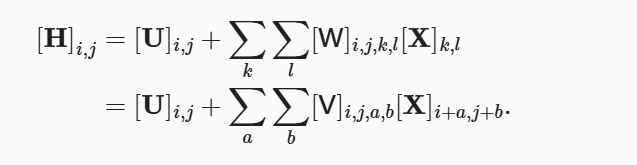
###### 可以看出权重同时依赖于输入位置和输出位置，而在图像处理中，我们通常关心的是局部信息，所以相对位置的权重才是更有意义的。  
###### 所以如何处理这个相对位置呢？  
###### 这里采用了坐标变换，从绝对坐标变成了相对坐标
###### 定义两个偏移量 a = k - i, b = l - j
###### 它们的物理意义是：
###### a 表示输出位置相对于输入位置的垂直偏量<br>b 表示输出位置相对于输入位置的水平偏移量
**接着进行变量替换：**<br>
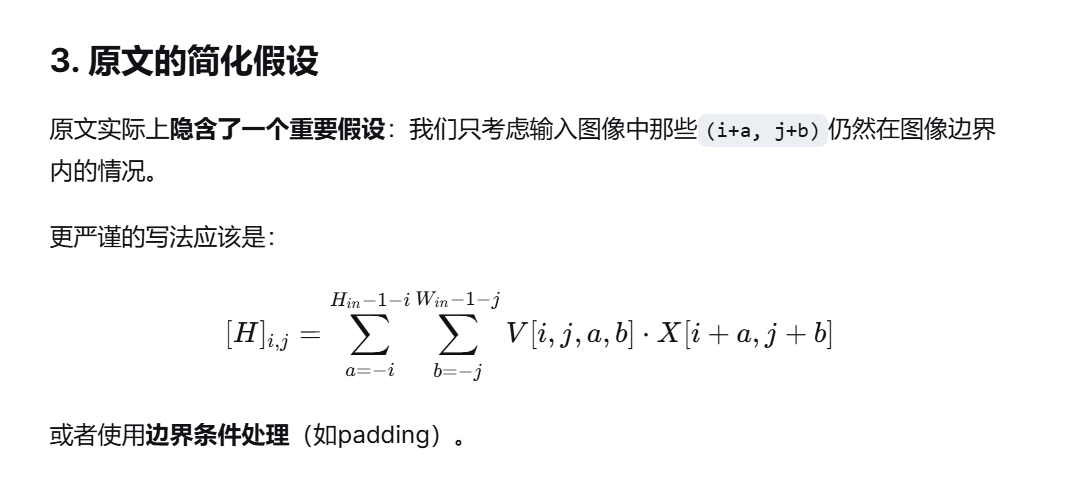<br>
**接下来应用平移不变性：**<br>
###### 如果我们将输入图像X平移几个像素，那么输出特征图H也应该相应地平移，但检测到的模式应该相同。也就是说，需要应用相同的权重，而这个权重又不能因为平移而改变。具体公式就是：
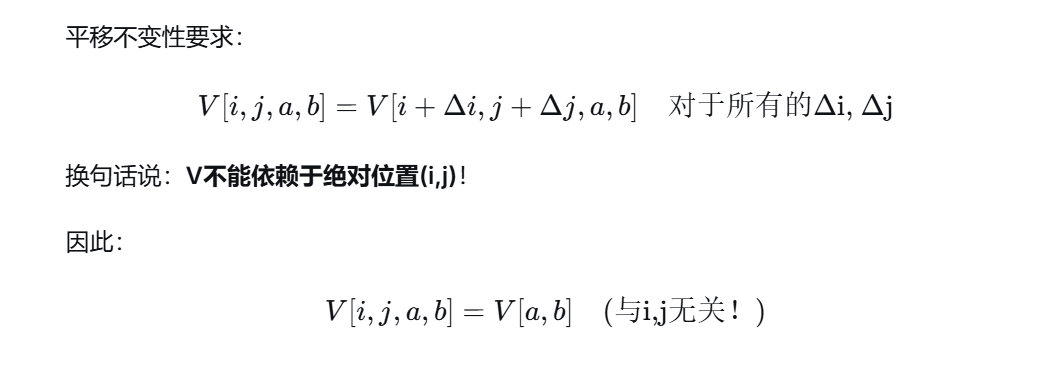<br>
###### 而U一般是一个常量，所以这时候我们就可以进一步的简化公式为：
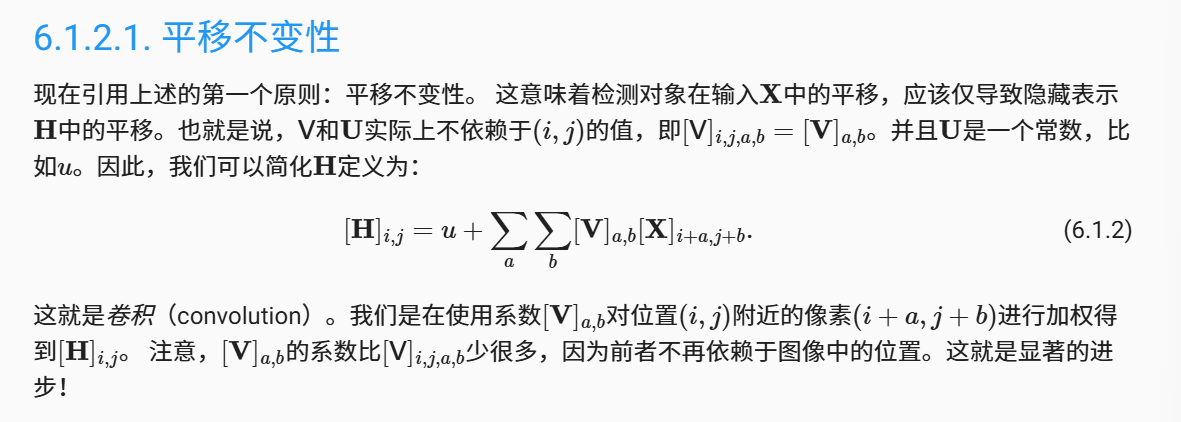<br>
**接下来考虑局部性原理：**
###### 即偏移的大小在一个区间内，也就是|a|, |b| < δ, 而大于的部分就可以将V设置为0，因为在这个区间内，权重是连续的，所以不会对结果产生影响。所以最终公式可重写为：
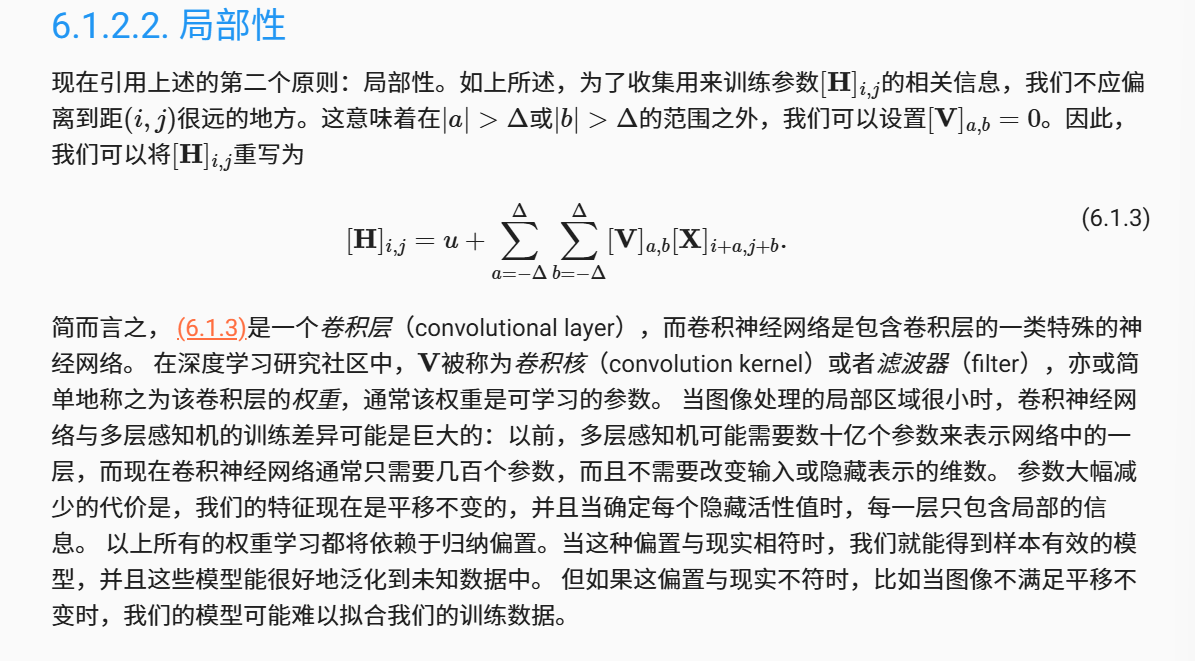<br>
###### 这里的V就叫做卷积核(convolution kernel)或者滤波器(filter)
**不过在具体的实现中由于图片其实还有一个通道维度**<br>
###### 所以卷积核也需要有一个通道维度，所以最终的卷积核形状为：(输出通道数, 输入通道数, 核高度, 核宽度)<br>
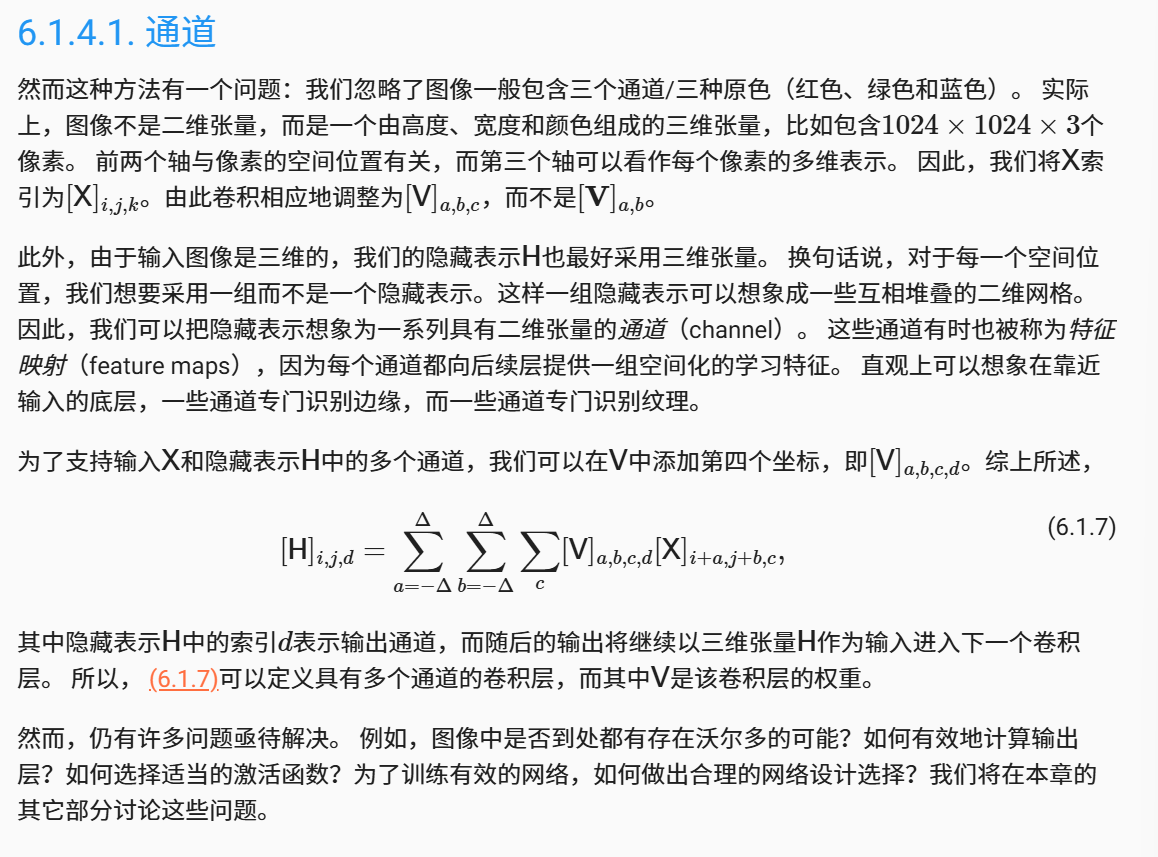


**这里讲一下数学中的卷积操作**
###### 因为在CNN中其实并不是数学意义上的卷积，而是二维交叉相关，它并没有进行翻转操作。但是CNN诞生于信号处理领域，借用了卷积思想，所以也叫卷积神经网络
###### 首先明确一下数学中卷积的意义：其实是一个函数在另一个函数的作用下，在不同位置上的响应强度
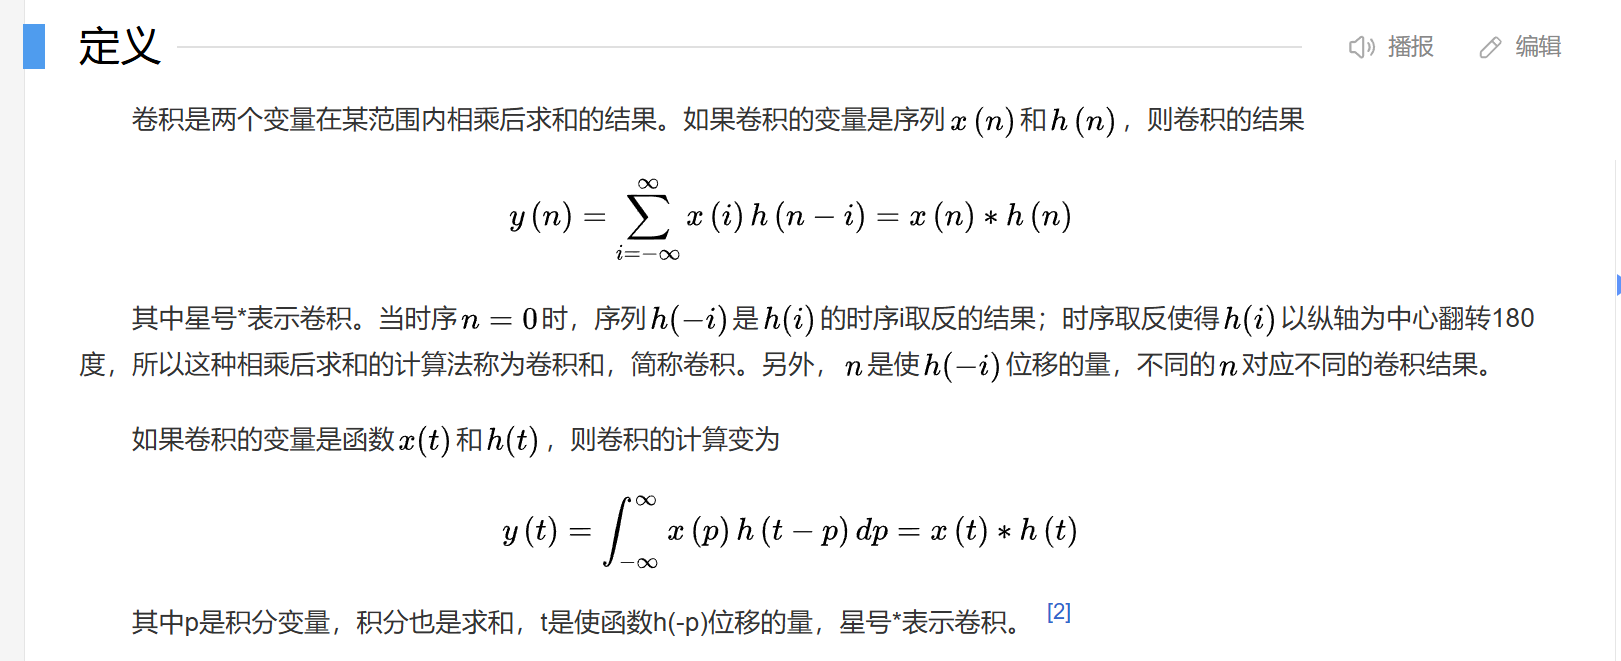

In [30]:
import torch 
from torch import nn
from d2l import torch as d2l

def corr2d(X, K): #@save
    """计算二维互相关运算"""
    h, w = K.shape # 卷积核的高度和宽度
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1)) # 输出的高度和宽度
    # 相乘相加
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y


In [31]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [32]:
# 卷积层
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter # 这里的weigth指的是卷积核里面的数值
        self.bias = nn.Parameter(torch.zeros(1)
        )
    
    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

In [33]:
# 这里是一个简单的应用，通过找到像素变化的位置，来检测图像中水平方向的边缘
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [34]:
K = torch.tensor([[1.0, -1.0]])
Y = corr2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [35]:
# 然而当我们将X转置后，卷积核K就无法检测到垂直方向的边缘了
corr2d(X.t(), K)

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

In [36]:
# 学习卷积核
conv2d = nn.Conv2d(1, 1, kernel_size=(1, 2), bias=False)

X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))



for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat-Y)**2
    conv2d.zero_grad()
    l.sum().backward()
    conv2d.weight.data[:] -= 3e-2 * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i+1}, loss {l.sum():.3f}')

epoch 2, loss 9.363
epoch 4, loss 2.664
epoch 6, loss 0.895
epoch 8, loss 0.334
epoch 10, loss 0.131


In [37]:
conv2d.weight.data.reshape((1, 2))

tensor([[ 1.0254, -0.9517]])